# Create figures for paper
**Developed by:** Anna Maguza\
**Affiliation:** Faculty of Medicine, Würzburg University\
**Creation date:** 3rd March 2024\
**Last modified date:** 3rd March 2024

### Import packages

In [1]:
import numpy as np
import scanpy as sc
import anndata
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import json
from matplotlib.colors import LogNorm
import matplotlib.colors as mcolors
import scipy
import gc

## Setup working environment

In [2]:
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi = 180, color_map = 'magma_r', dpi_save = 300, vector_friendly = True, format = 'svg')

In [3]:
timestamp = datetime.now().strftime('%d%m%Y_%H%M%S')

In [4]:
timestamp

'03032025_180330'

### Load object

In [84]:
adata = sc.read_h5ad('data/gut_data/gut_hs_all_datasets_full_annotated_AM_03032025_141544_raw.h5ad')

In [5]:
adata_log = sc.read_h5ad('data/gut_data/gut_hs_all_datasets_full_annotated_AM_03032025_175437_log.h5ad')

### Supplelementary figure 1A

In [6]:
adata.obs['age_group'].value_counts()

age_group
second trimester      169380
first trimester       148150
adult                  32301
cell culture model     20533
child stage            16712
Name: count, dtype: int64

In [16]:
sample_age_counts = adata.obs.groupby('age_group')['sample_id'].nunique()

print("Number of unique samples in each age group:")
for age_group, count in sample_age_counts.items():
    print(f"{age_group}: {count}")

Number of unique samples in each age group:
adult: 50
cell culture model: 11
child stage: 8
first trimester: 32
second trimester: 25


/var/folders/kr/nd4y_1_s34n42lrht8wdh4cr0000gq/T/ipykernel_5171/1987776253.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sample_age_counts = adata.obs.groupby('age_group')['sample_id'].nunique()


### Figure 1A

In [8]:
adata_filtered = adata[adata.obs['age_group'].isin(['adult', 'child stage'])].copy()

In [9]:
samples_per_organism_part = adata_filtered.obs.groupby('organism_part')['sample_id'].nunique()
samples_per_organism_part

/var/folders/kr/nd4y_1_s34n42lrht8wdh4cr0000gq/T/ipykernel_6794/3169073530.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  samples_per_organism_part = adata_filtered.obs.groupby('organism_part')['sample_id'].nunique()


organism_part
appendix             6
ascending colon      5
caecum               5
descending colon     3
duodenum             3
ileum               10
jejunum              3
rectum               2
sigmoid colon        6
terminal ileum       8
transverse colon     7
Name: sample_id, dtype: int64

In [10]:
cells_per_region = adata_filtered.obs['organism_part'].value_counts()
cells_per_region

organism_part
terminal ileum      16712
ileum                8883
sigmoid colon        7020
caecum               5202
transverse colon     3969
ascending colon      2382
appendix             2277
descending colon      882
duodenum              657
jejunum               627
rectum                402
Name: count, dtype: int64

In [11]:
adata_filtered = adata[adata.obs['age_group'].isin(['second trimester', 'first trimester'])].copy()

In [12]:
samples_per_organism_part = adata_filtered.obs.groupby('organism_part')['sample_id'].nunique()
samples_per_organism_part

/var/folders/kr/nd4y_1_s34n42lrht8wdh4cr0000gq/T/ipykernel_6794/3169073530.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  samples_per_organism_part = adata_filtered.obs.groupby('organism_part')['sample_id'].nunique()


organism_part
colon               9
duodenum           18
ileum              23
large intestine     5
small intestine     2
Name: sample_id, dtype: int64

In [13]:
cells_per_region = adata_filtered.obs['organism_part'].value_counts()
cells_per_region

organism_part
duodenum           207729
ileum               42654
small intestine     39925
colon               20409
large intestine      6813
Name: count, dtype: int64

In [14]:
adata_filtered = adata[adata.obs['age_group'].isin(['cell culture model'])].copy()

In [15]:
samples_per_organism_part = adata_filtered.obs.groupby('organism_part')['sample_id'].nunique()
samples_per_organism_part

/var/folders/kr/nd4y_1_s34n42lrht8wdh4cr0000gq/T/ipykernel_6794/3169073530.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  samples_per_organism_part = adata_filtered.obs.groupby('organism_part')['sample_id'].nunique()


organism_part
duodenum    5
ileum       6
Name: sample_id, dtype: int64

In [16]:
cells_per_region = adata_filtered.obs['organism_part'].value_counts()
cells_per_region

organism_part
ileum       11707
duodenum     8826
Name: count, dtype: int64


Color codes for each region:

Adult samples:
ileum: 25663 cells -> #30698e
sigmoid_colon: 7047 cells -> #1e9b8a
caecum: 5235 cells -> #21a685
transverse_colon: 3975 cells -> #2cb17e
ascending_colon: 2418 cells -> #4cc26c
appendix: 2325 cells -> #50c46a
descending_colon: 897 cells -> #addc30
duodenum: 669 cells -> #cde11d
jejunum: 630 cells -> #d2e21b
rectum: 417 cells -> #fde725

Fetal samples:
duodenum: 207781 cells -> #440154
ileum: 82680 cells -> #46337f
colon: 27289 cells -> #31668e

Cell culture samples:
ileum: 11748 cells -> #24878e
duodenum: 10558 cells -> #228b8d


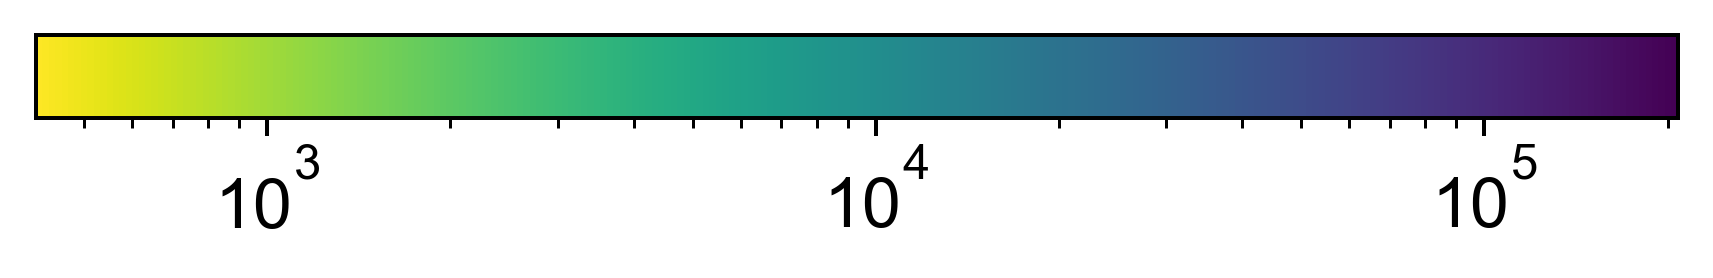

In [17]:
data = {
    'adult': {
        'ileum': 25663,
        'sigmoid_colon': 7047,
        'caecum': 5235,
        'transverse_colon': 3975,
        'ascending_colon': 2418,
        'appendix': 2325,
        'descending_colon': 897,
        'duodenum': 669,
        'jejunum': 630,
        'rectum': 417
    },
    'fetal': {
        'duodenum': 207781,
        'ileum': 82680,
        'colon': 27289
    },
    'cell_culture': {
        'ileum': 11748,
        'duodenum': 10558
    }
}

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 2))

# Create colormap
vmin = 417  # minimum value
vmax = 207781  # maximum value
norm = LogNorm(vmin=vmin, vmax=vmax)
cmap = plt.cm.viridis_r  # Using viridis colormap

# Create colorbar
cb = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap),
                 ax=ax,
                 orientation='horizontal')

# Remove the dummy image
ax.remove()

# Function to get hex color for a value
def get_color_for_value(value):
    normalized_value = norm(value)
    rgba = cmap(normalized_value)
    return mcolors.rgb2hex(rgba)

# Print color codes for each data point
print("\nColor codes for each region:")
print("\nAdult samples:")
for region, value in data['adult'].items():
    color = get_color_for_value(value)
    print(f"{region}: {value} cells -> {color}")

print("\nFetal samples:")
for region, value in data['fetal'].items():
    color = get_color_for_value(value)
    print(f"{region}: {value} cells -> {color}")

print("\nCell culture samples:")
for region, value in data['cell_culture'].items():
    color = get_color_for_value(value)
    print(f"{region}: {value} cells -> {color}")
#plt.savefig(f"8_figures_for_paper_creation/figures/colormap_cells_per_region_{timestamp}.png", dpi=300, bbox_inches='tight')
plt.show()

### Figure 1B

In [ ]:
adata.obs['age_group_copy'] = adata.obs['age_group'].copy()

In [19]:
category_map = {'adult': 'adult & adolescent', 'child stage': 'adult & adolescent'}
adata.obs['age_group_copy'] = adata.obs['age_group_copy'].map(lambda x: category_map.get(x, x))
adata.obs['age_group_copy'] = adata.obs['age_group_copy'].astype('category')

In [20]:
adata = adata[~((adata.obs['age_group'] == 'cell culture model') & 
                (~adata.obs['celltype'].isin(['Epithelial', 'Mesenchymal'])))]

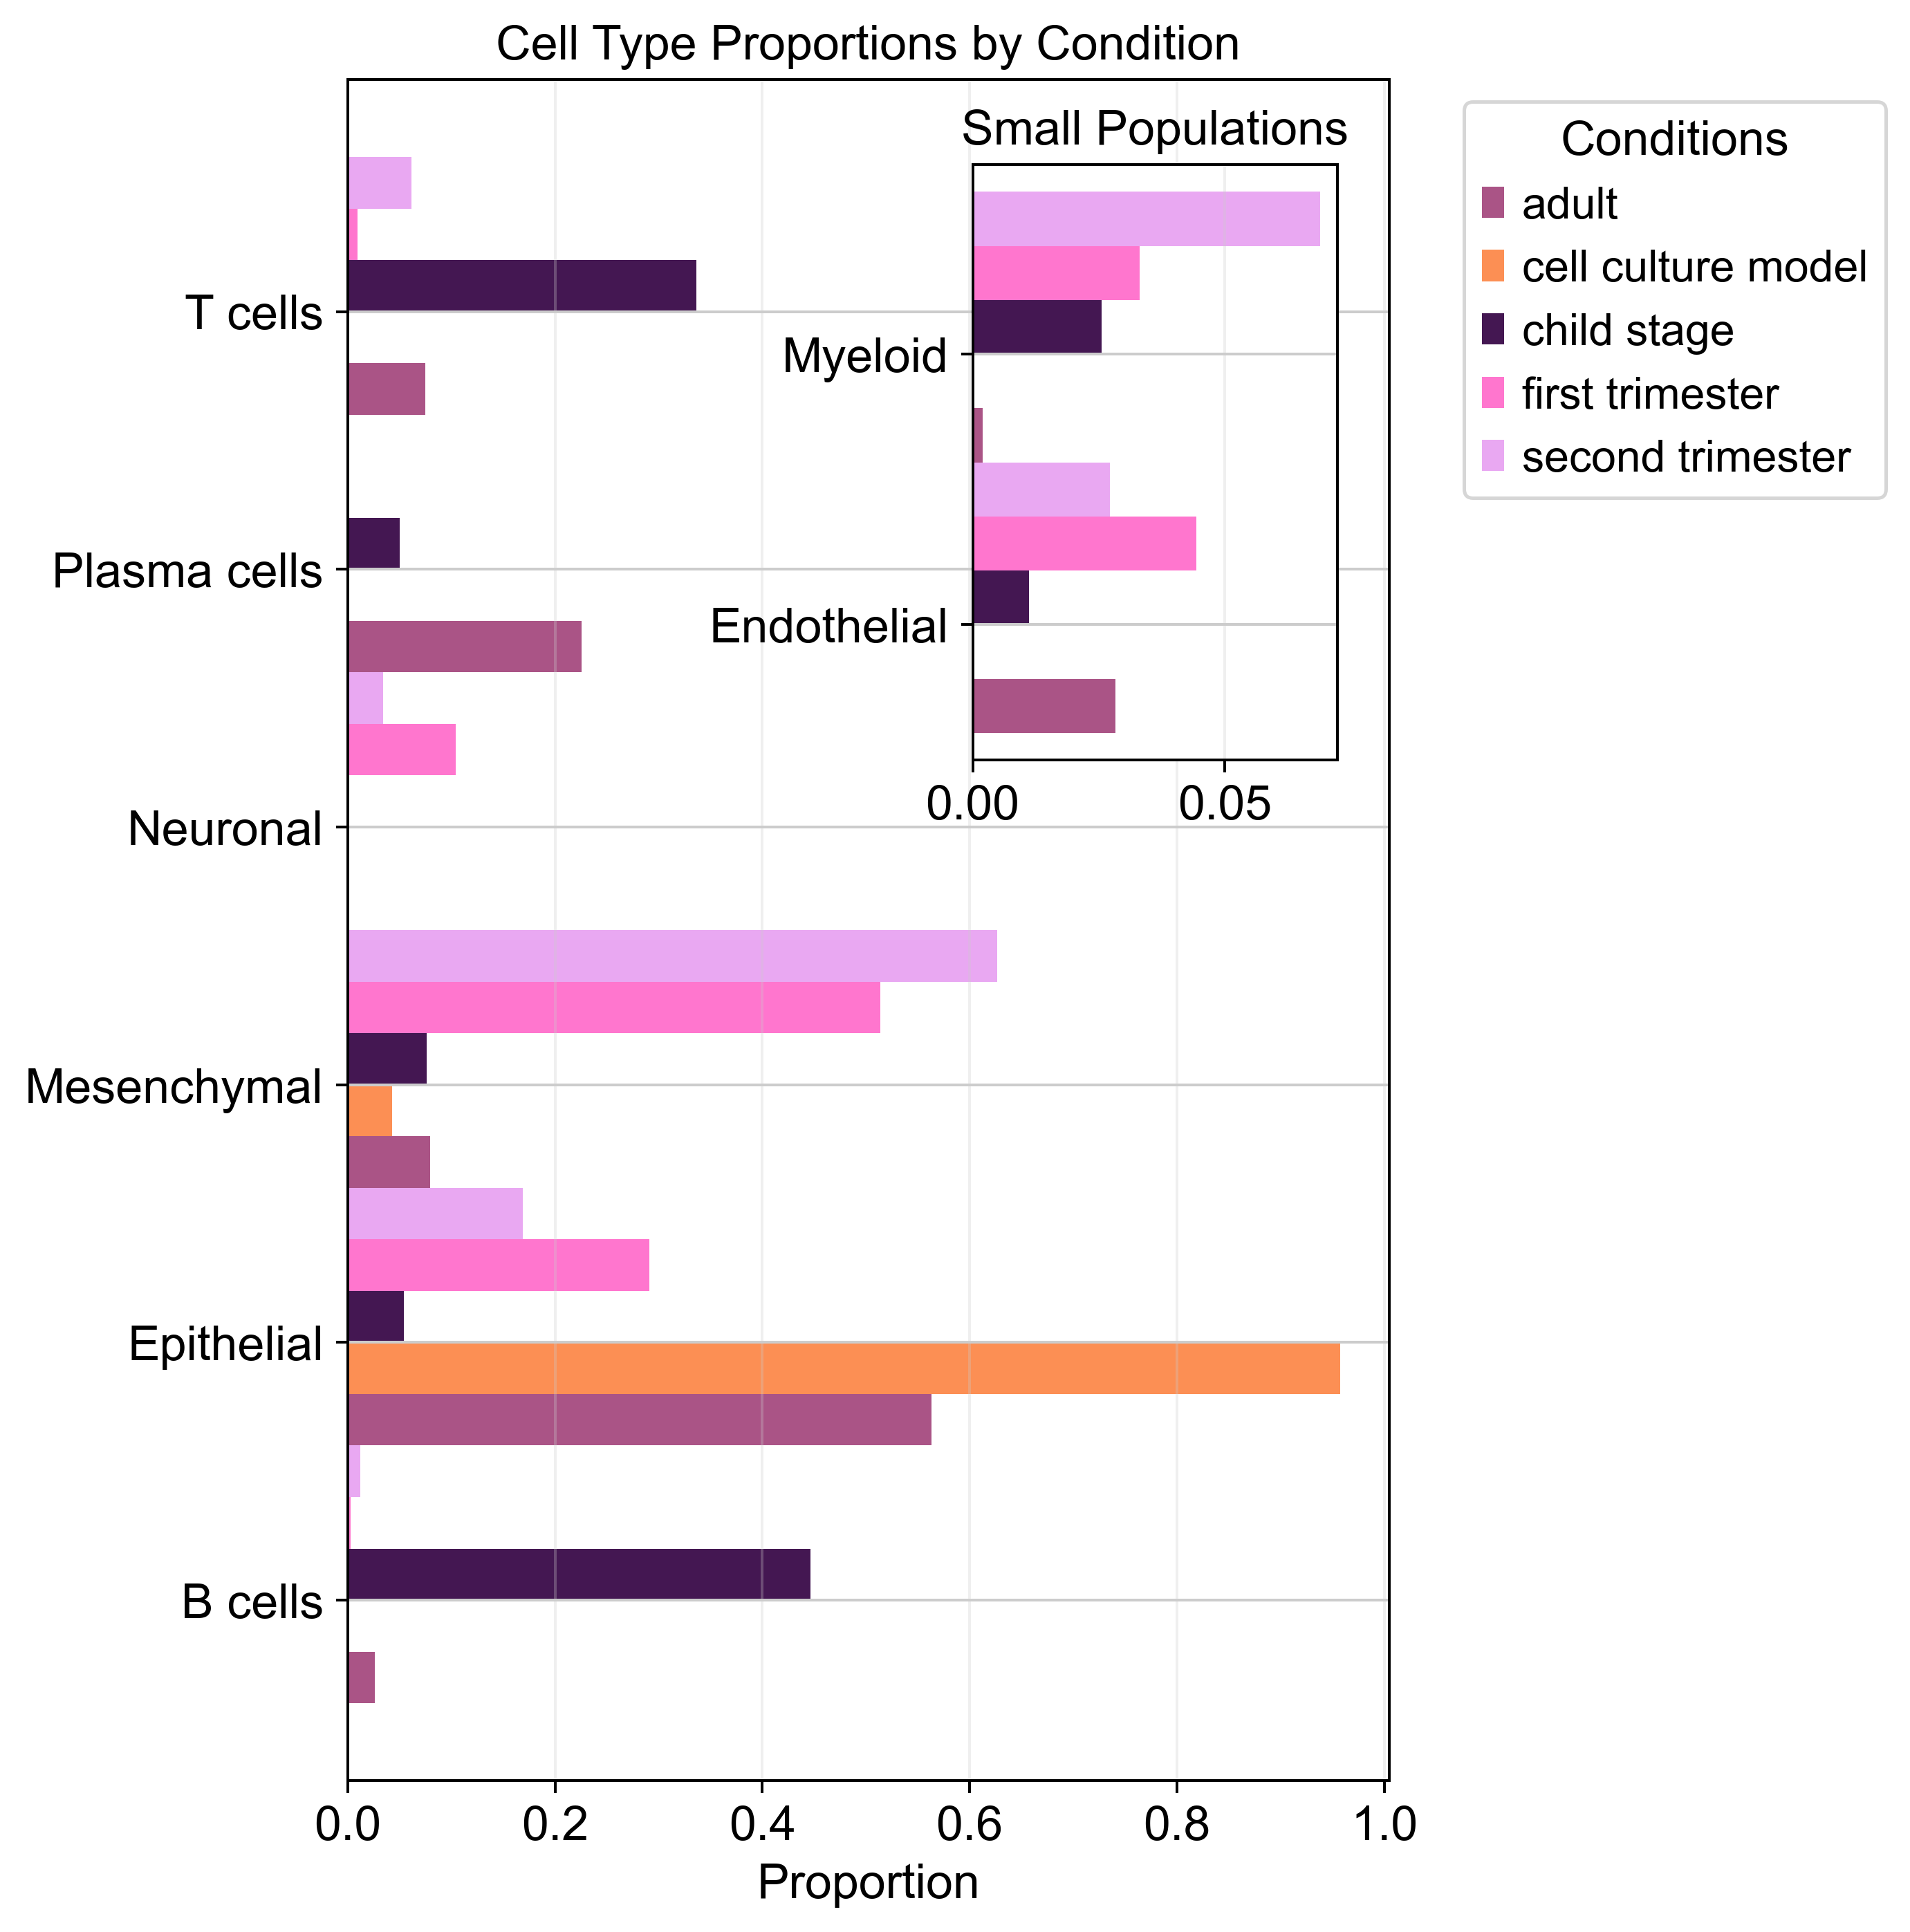

In [ ]:
# Define bar properties
bar_height = 0.2  # Controls the thickness of each bar
                 # and spacing between groups

def create_horizontal_bars(ax, data, colors, height=bar_height):
    y = np.arange(len(data.index))
    for i, (condition, color) in enumerate(zip(data.columns, colors)):
        ax.barh(y + i*height, data[condition], height, label=condition, color=color)
    return y

# Calculate proportions
proportions = pd.crosstab(adata.obs['celltype'], adata.obs['age_group'], normalize='columns')

# Color scheme
colors = ['#AA5486',  # bright pink
                '#FC8F54',  # light lavender
                '#441752',  # mint green
                '#FF76CE',  # light sky blue
                '#E9A8F2',  # light coral
                '#982B1C',  # bricks color
                '#43766C',  #dark teal
                ]  # pink, purple, light green, light blue

# Create figure
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111)

# Separate large and small proportions
threshold = 0.1  # Adjust this threshold based on your data
max_vals = proportions.max(axis=1)
large_props = proportions[max_vals >= threshold]
small_props = proportions[max_vals < threshold]

# Plot large proportions in main axis
y = create_horizontal_bars(ax, large_props, colors)
ax.set_yticks(y + bar_height*1.5)
ax.set_yticklabels(large_props.index, ha='right')
ax.set_xlabel('Proportion')
ax.set_title('Cell Type Proportions by Condition')

# Add grid lines
ax.grid(True, axis='x', alpha=0.3)

# Create inset axes for small proportions
# Adjust these values to position the inset where you want it
ax_inset = ax.inset_axes([0.6, 0.6, 0.35, 0.35])

# Plot small proportions in inset
y_small = create_horizontal_bars(ax_inset, small_props, colors)
ax_inset.set_yticks(y_small + bar_height*1.5)
ax_inset.set_yticklabels(small_props.index, ha='right')
ax_inset.set_title('Small Populations')
ax_inset.grid(True, axis='x', alpha=0.3)

# Add legend outside the plot
ax.legend(title='Conditions', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout
plt.tight_layout()

# Save the figure
plt.savefig(f"8_figures_for_paper_creation/figures/cell_type_proportions_{timestamp}.png", dpi=300, bbox_inches='tight')

plt.show()

First few rows of the counts table:
age_group    adult  cell culture model  child stage  first trimester  \
celltype                                                               
B cells        855                   0         7460              449   
Endothelial    912                   0          187             6574   
Epithelial   18192               19294          907            43115   
Mesenchymal   2577                 861         1269            76169   
Myeloid         63                   0          427             4905   

age_group    second trimester  
celltype                       
B cells                  2112  
Endothelial              4617  
Epithelial              28597  
Mesenchymal            106102  
Myeloid                 11665  

Threshold for separating large and small populations: 11041.5

Number of large populations: 4
Number of small populations: 4


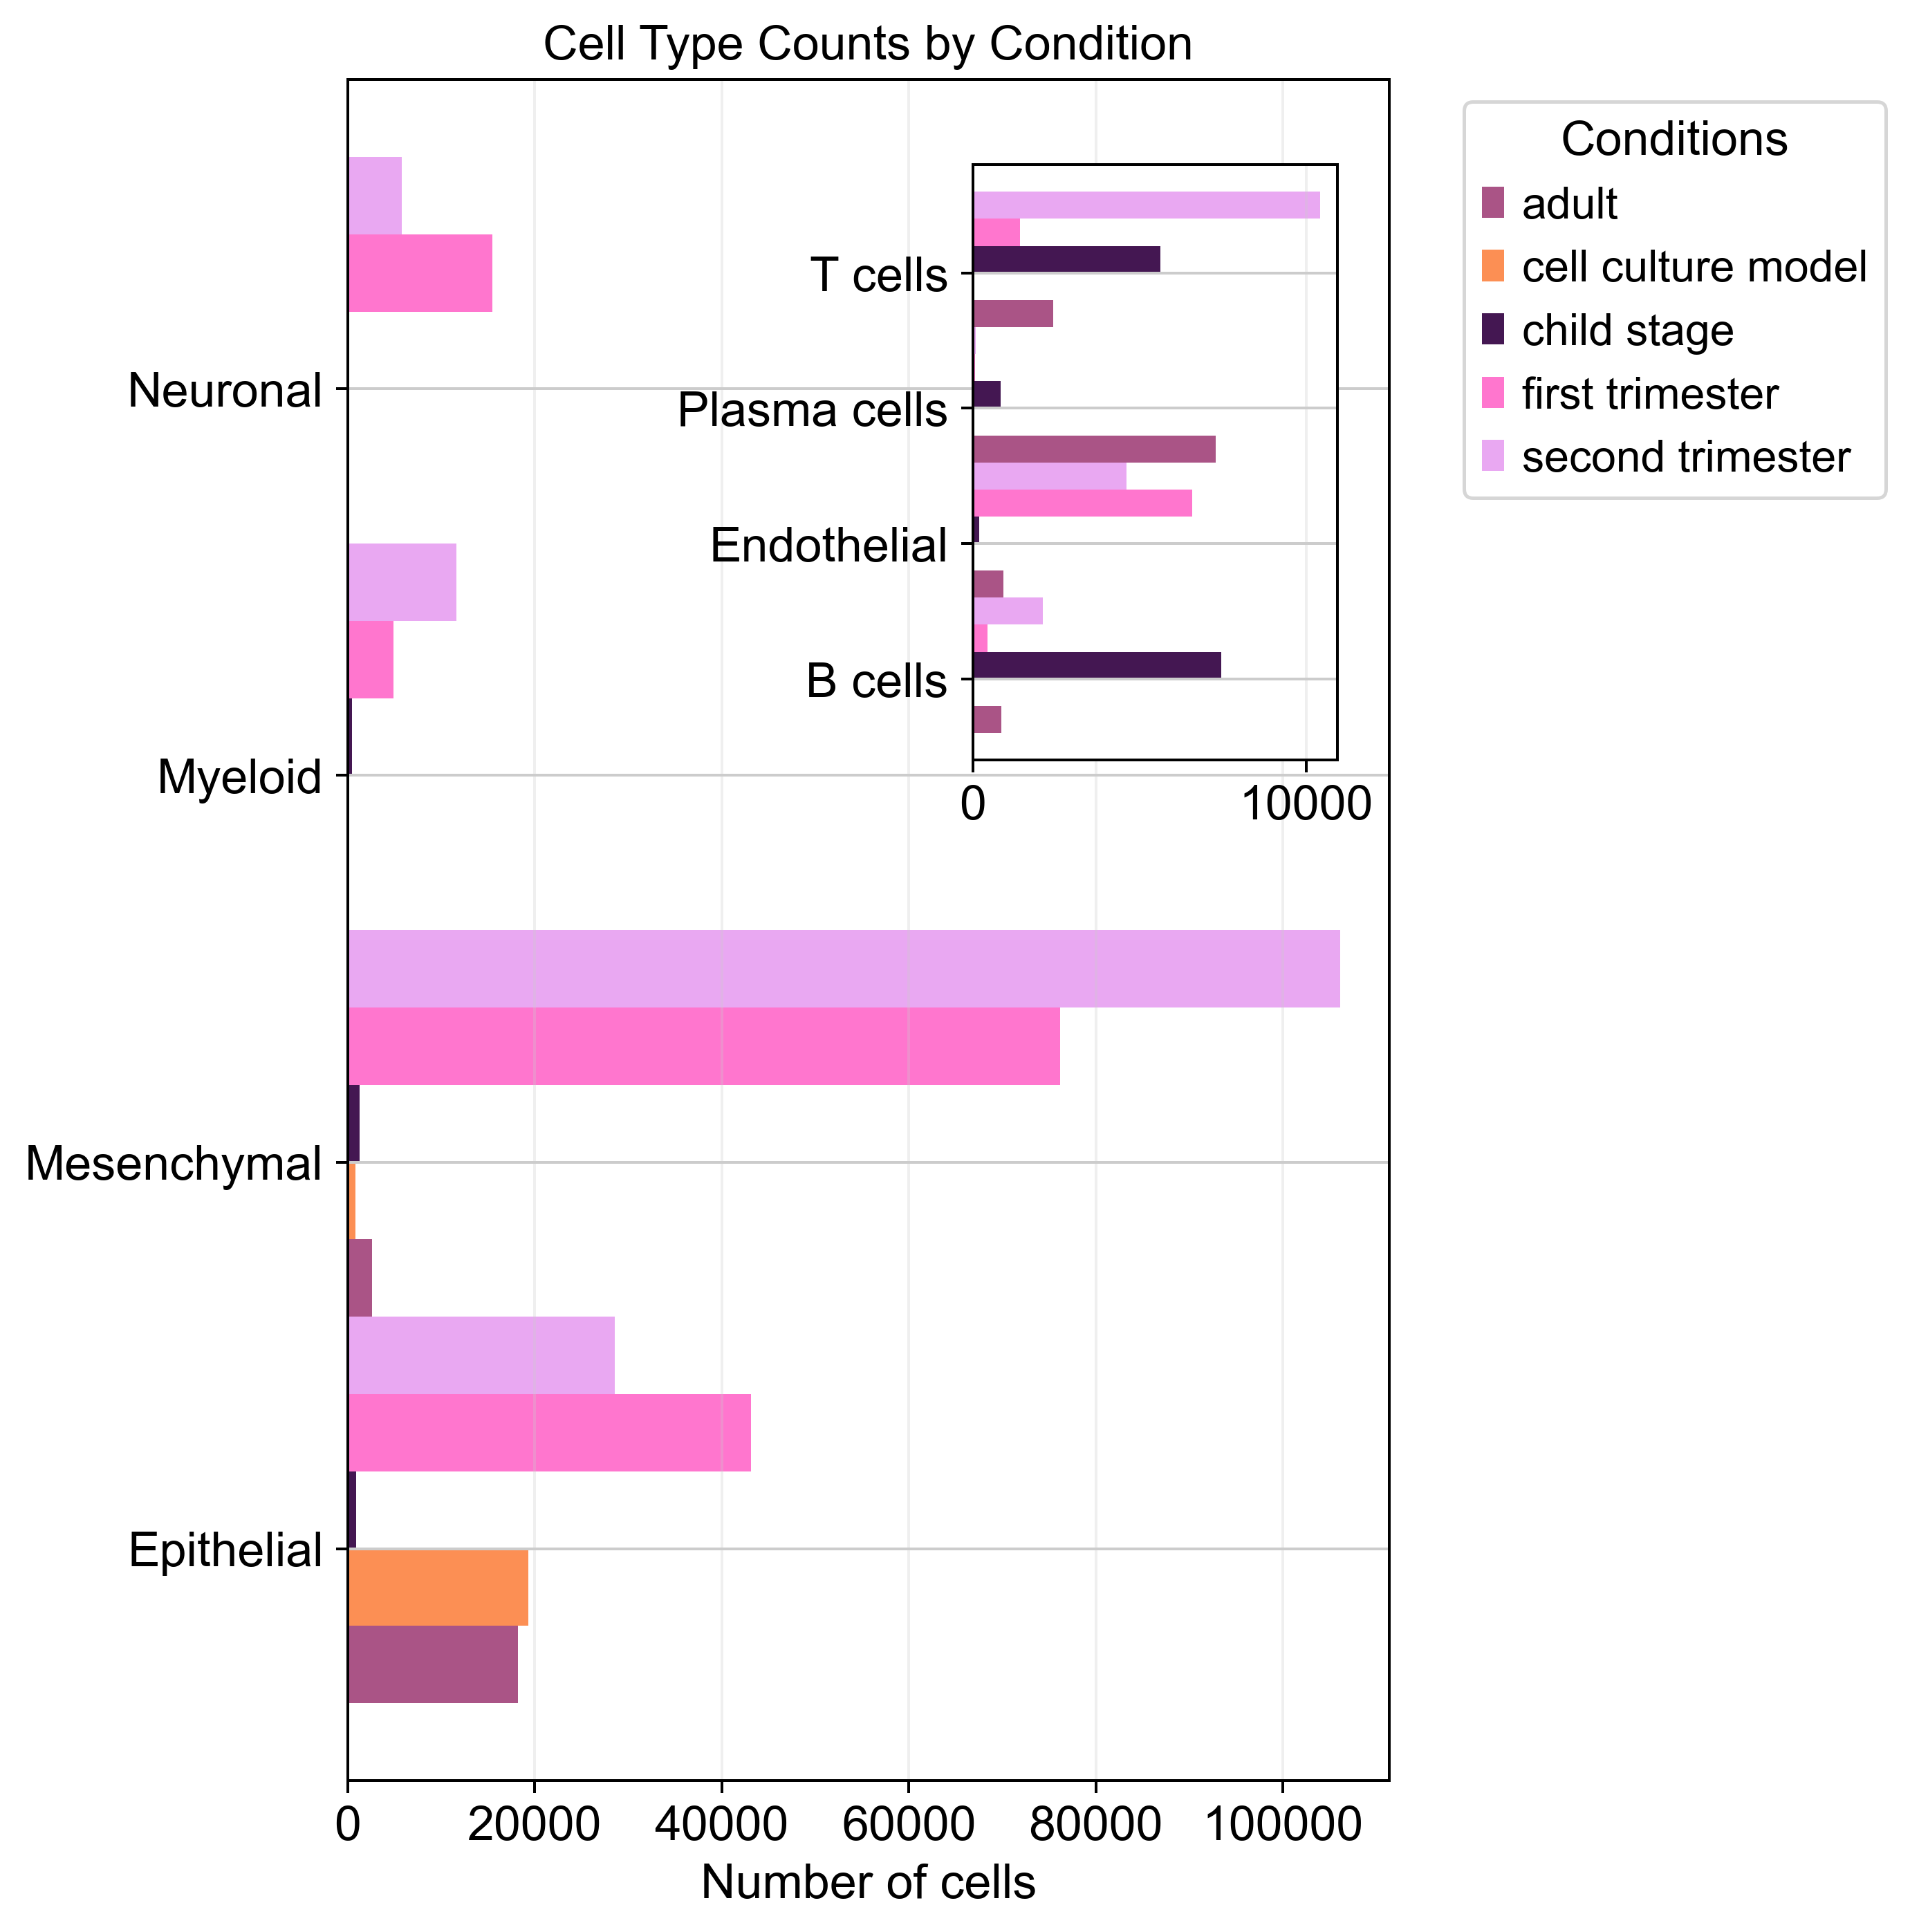

In [22]:
bar_height = 0.2  # Controls the thickness of each bar and spacing between groups

def create_horizontal_bars(ax, data, colors, height=bar_height):
    y = np.arange(len(data.index))
    for i, (condition, color) in enumerate(zip(data.columns, colors)):
        ax.barh(y + i*height, data[condition], height, label=condition, color=color)
    return y

# Calculate cell counts from AnnData object
counts = pd.crosstab(adata.obs['celltype'], adata.obs['age_group'])

# Print the first few rows to verify the data
print("First few rows of the counts table:")
print(counts.head())

# Create figure
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111)

# Separate large and small counts
threshold = np.median(counts.max(axis=1))  # Adjust threshold based on counts
print(f"\nThreshold for separating large and small populations: {threshold}")
max_vals = counts.max(axis=1)
large_counts = counts[max_vals >= threshold]
small_counts = counts[max_vals < threshold]

print(f"\nNumber of large populations: {len(large_counts)}")
print(f"Number of small populations: {len(small_counts)}")

# Plot large counts in main axis
y = create_horizontal_bars(ax, large_counts, colors)
ax.set_yticks(y + bar_height*1.5)
ax.set_yticklabels(large_counts.index, ha='right')
ax.set_xlabel('Number of cells')
ax.set_title('Cell Type Counts by Condition')

# Add grid lines
ax.grid(True, axis='x', alpha=0.3)

# Create inset axes for small populations
ax_inset = ax.inset_axes([0.6, 0.6, 0.35, 0.35])

# Plot small counts in inset
y_small = create_horizontal_bars(ax_inset, small_counts, colors)
ax_inset.set_yticks(y_small + bar_height*1.5)
ax_inset.set_yticklabels(small_counts.index, ha='right')
ax_inset.grid(True, axis='x', alpha=0.3)

# Add legend outside the plot
ax.legend(title='Conditions', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout
plt.tight_layout()

# Save the figure
plt.savefig(f"8_figures_for_paper_creation/figures/cell_type_proportions_cell_number_{timestamp}.png", dpi=300, bbox_inches='tight')

plt.show()

## Figure 1C

In [ ]:
adata_log = adata.copy()
sc.pp.normalize_total(adata_log, target_sum=1e6, exclude_highly_expressed=True)
sc.pp.log1p(adata_log)

In [10]:
category_map = {'adult': 'adult & adolescent', 'child stage': 'adult & adolescent'}
adata_log.obs['age_group'] = adata_log.obs['age_group'].map(lambda x: category_map.get(x, x))
adata_log.obs['age_group'] = adata_log.obs['age_group'].astype('category')

In [11]:
adata_log.obs['cell_states'] = adata_log.obs['cell_states'].astype(str)
adata_log.obs['gut_region'] = adata_log.obs['gut_region'].astype(str)
adata_log.obs['cell_states_and_gut_region'] = adata_log.obs['cell_states'] + '_' + adata_log.obs['gut_region']
adata_log.obs['cell_states_and_gut_region'].value_counts()

cell_states_and_gut_region
Mesoderm 2(ZEB2+)_small intestine         64860
Enterocyte_small intestine                26785
Stromal 1 (ADAMDEC1+)_small intestine     23398
Proximal progenitor_small intestine       21145
Myofibroblast (RSPO2+)_small intestine    20189
                                          ...  
EC cells (TAC1+)_large intestine              4
Megakaryocyte_large intestine                 3
L cells (PYY+)_large intestine                3
Migratory DC_large intestine                  1
D cells (SST+)_large intestine                1
Name: count, Length: 187, dtype: int64

In [12]:
def calculate_expression_stats(adata, genes, groupby='age_group', cell_type_col='cell_states_and_gut_region'):
    """Calculate percentage of expressing cells and mean expression for each group in a memory-efficient way."""
    results = []
    
    # Get gene indices upfront to avoid repeated lookups
    gene_indices = {gene: adata.var_names.get_loc(gene) for gene in genes if gene in adata.var_names}
    missing_genes = [gene for gene in genes if gene not in adata.var_names]
    if missing_genes:
        print(f"Warning: The following genes were not found: {missing_genes}")
    
    # Process each group and cell type combination
    for group in adata.obs[groupby].unique():
        print(f"Processing group: {group}")
        
        for cell_type in ['Stem cells_small intestine', 'Stem cells_large intestine']:
            # Create mask for this group and cell type
            mask = (adata.obs[groupby] == group) & (adata.obs[cell_type_col] == cell_type)
            mask_indices = np.where(mask)[0]
            
            if len(mask_indices) == 0:  # Skip if no cells in this group
                print(f"  No cells found for {cell_type} in {group}")
                continue
            
            print(f"  Processing {cell_type}: {len(mask_indices)} cells")
            
            # Process each gene one at a time to avoid large memory allocations
            for gene, gene_idx in gene_indices.items():
                # Extract expression values for this gene efficiently
                if scipy.sparse.issparse(adata.X):
                    # Get only the specific cells and gene we need without converting the whole matrix
                    expr = adata.X[mask_indices, gene_idx].toarray().flatten()
                else:
                    expr = adata.X[mask_indices, gene_idx]
                
                # Calculate metrics
                expressing_mask = expr > 0
                pct = np.mean(expressing_mask) * 100
                mean_expr = np.mean(expr[expressing_mask]) if np.any(expressing_mask) else 0
                
                # Store results
                results.append({
                    'group': group,
                    'cell_type': cell_type,
                    'gene': gene,
                    'pct_expressed': pct,
                    'mean_expression': mean_expr,
                    'num_cells': len(mask_indices)
                })
                
                # Clean up to be extra careful
                del expr, expressing_mask
            
            # Force garbage collection after each cell type
            gc.collect()
    
    return pd.DataFrame(results)

In [13]:
# Assuming we have genes grouped by categories
gene_categories = {
    'Stem cells markers': ['LGR5', 'ASCL2', 'OLFM4', 'SMOC2', 'RGMB'],
    'Early stem markers': ['GATA4', 'VTN', 'ONECUT2']
}

# Flatten gene list
all_genes = [gene for genes in gene_categories.values() for gene in genes]

In [14]:
stats_df = calculate_expression_stats(adata_log, all_genes)

Processing group: cell culture model
  Processing Stem cells_small intestine: 3439 cells
  No cells found for Stem cells_large intestine in cell culture model
Processing group: second trimester
  Processing Stem cells_small intestine: 3446 cells
  Processing Stem cells_large intestine: 155 cells
Processing group: first trimester
  Processing Stem cells_small intestine: 3298 cells
  Processing Stem cells_large intestine: 409 cells
Processing group: adult & adolescent
  Processing Stem cells_small intestine: 1431 cells
  Processing Stem cells_large intestine: 1317 cells


In [15]:
stats_df

,group,cell_type,gene,pct_expressed,mean_expression,num_cells
0,cell culture model,Stem cells_small intestine,LGR5,10.962489,4.966421,3439
1,cell culture model,Stem cells_small intestine,ASCL2,18.784530,5.577993,3439
2,cell culture model,Stem cells_small intestine,OLFM4,32.276825,8.178954,3439
3,cell culture model,Stem cells_small intestine,SMOC2,15.905787,5.583682,3439
4,cell culture model,Stem cells_small intestine,RGMB,0.901425,4.819239,3439
5,cell culture model,Stem cells_small intestine,GATA4,0.610643,4.767405,3439
6,cell culture model,Stem cells_small intestine,VTN,18.348357,5.308838,3439
7,cell culture model,Stem cells_small intestine,ONECUT2,51.671998,5.444968,3439
8,second trimester,Stem cells_small intestine,LGR5,43.934997,5.413584,3446
9,second trimester,Stem cells_small intestine,ASCL2,52.031341,5.986897,3446


/var/folders/kr/nd4y_1_s34n42lrht8wdh4cr0000gq/T/ipykernel_8566/2143883448.py:118: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


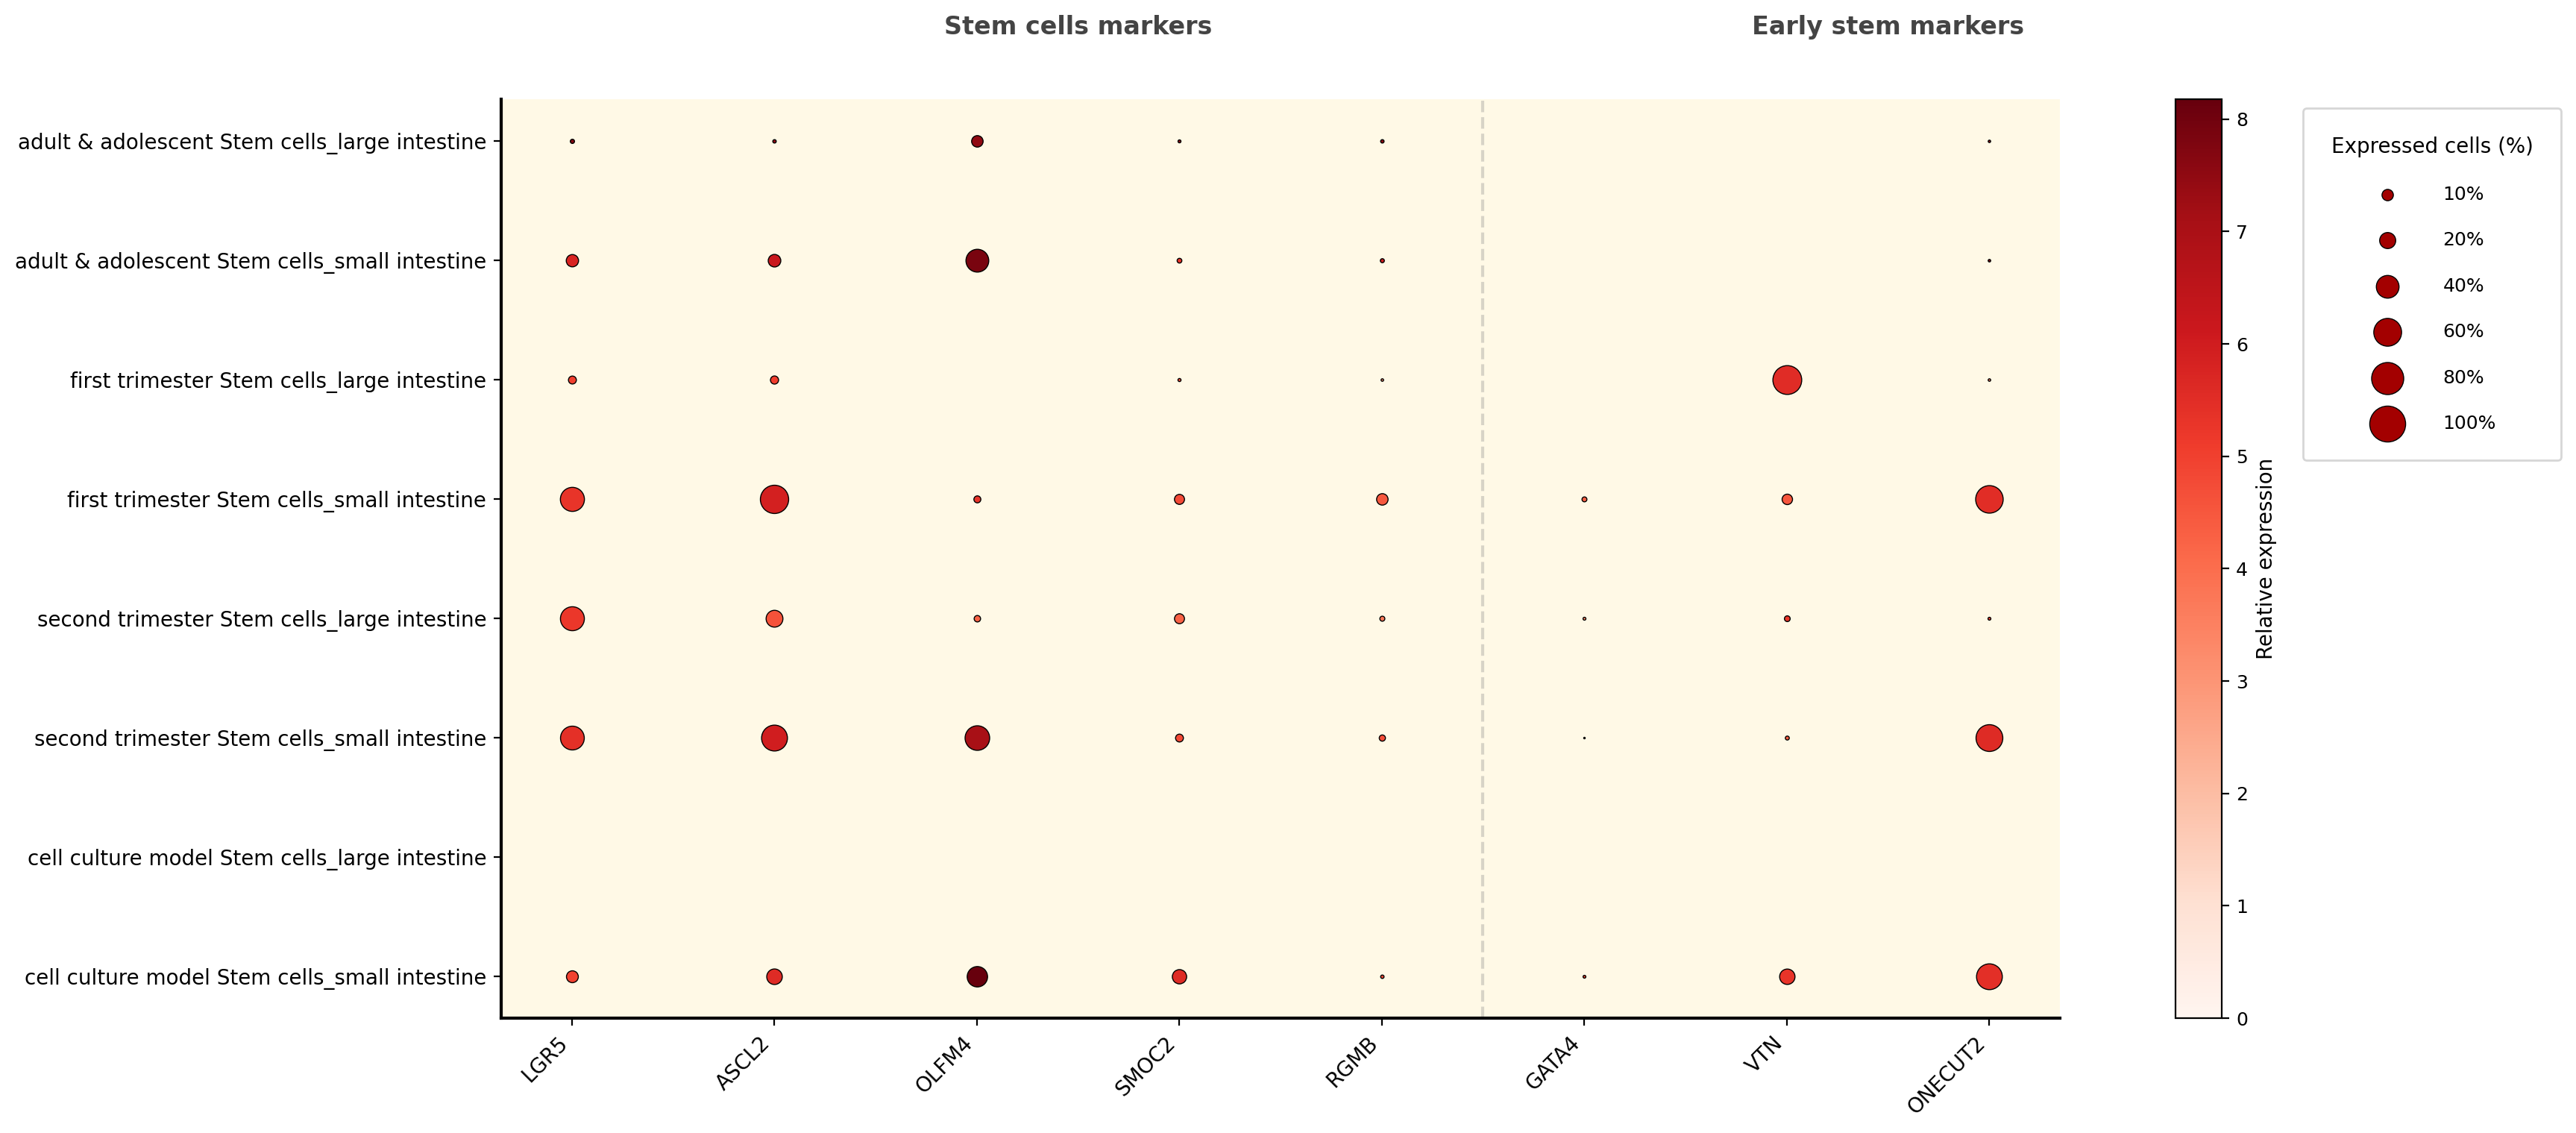

In [16]:
# Create the plot with explicit axes
plt.style.use('default')
fig = plt.figure(figsize=(15, 8))
gs = plt.GridSpec(1, 20)
ax = fig.add_subplot(gs[:, :18])  # Main plot
cax = fig.add_subplot(gs[:, 19])  # Colorbar axis

# Set background colors
ax.set_facecolor('#FFF9E6')  # Light yellow background
fig.patch.set_facecolor('white')

# Set up the grid for the plot
groups = adata_log.obs['age_group'].unique()
cell_types = ['Stem cells_small intestine', 'Stem cells_large intestine']
genes = all_genes

# Plot dots
for i, group in enumerate(groups):
    for j, cell_type in enumerate(cell_types):
        for k, gene in enumerate(genes):
            data = stats_df[
                (stats_df['group'] == group) &
                (stats_df['cell_type'] == cell_type) &
                (stats_df['gene'] == gene)
            ]
            
            if not data.empty:
                size = data['pct_expressed'].iloc[0]
                color = data['mean_expression'].iloc[0]
                
                ax.scatter(
                    k, 
                    i*2 + j,
                    s=size*3,  # Reduced base size multiplier
                    c=[color],
                    cmap='Reds',
                    vmin=0,
                    vmax=stats_df['mean_expression'].max(),
                    edgecolor='black',
                    linewidth=0.5
                )

# Customize the plot
ax.set_yticks(
    np.arange(len(groups)*2),
    [f"{group} {cell_type}" for group in groups for cell_type in cell_types],
    fontsize=10
)

ax.set_xticks(
    range(len(all_genes)),
    all_genes,
    rotation=45,
    ha='right',
    fontsize=10
)

# Add spines styling
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    
# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add gene category labels with enhanced styling
category_positions = []
current_pos = 0
for category, genes in gene_categories.items():
    category_positions.append((current_pos + len(genes)/2, category))
    current_pos += len(genes)
    if current_pos < len(all_genes):
        ax.axvline(x=current_pos-0.5, color='gray', linestyle='--', alpha=0.3)

for pos, category in category_positions:
    ax.text(pos, ax.get_ylim()[1] + 0.5, category, 
            ha='center', va='bottom', 
            fontsize=12, fontweight='bold', 
            color='#444444')

# Modified legend for dot size with increased spacing
sizes = [10, 20, 40, 60, 80, 100]
legend_elements = []
for s in sizes:
    # Create scatter plot with adjusted size
    scatter = plt.scatter([], [], 
                         s=s*3,  # Reduced base size multiplier
                         c='#A30000', 
                         label=f'{s}%', 
                         edgecolor='black', 
                         linewidth=0.5)
    legend_elements.append(scatter)

# Create legend with increased spacing
legend = ax.legend(handles=legend_elements, 
                  title='Expressed cells (%)', 
                  bbox_to_anchor=(1.15, 1), 
                  loc='upper left',
                  title_fontsize=10,
                  fontsize=9,
                  labelspacing=1.5,  # Increased spacing between legend items
                  handletextpad=2,   # Increased spacing between dot and text
                  borderpad=1.5)     # Increased padding inside legend

# Add colorbar for expression levels with modified styling
sm = plt.cm.ScalarMappable(cmap='Reds', 
                          norm=plt.Normalize(vmin=0, 
                                           vmax=stats_df['mean_expression'].max()))

# Modified colorbar with reduced width
cbar = plt.colorbar(sm, cax=cax, label='Relative expression')
cbar.ax.tick_params(labelsize=9)
cbar.ax.set_ylabel('Relative expression', fontsize=10)

# Adjust colorbar width
cax.set_box_aspect(20)  # Make colorbar more narrow

plt.tight_layout()

# Save the plot
plt.savefig('8_figures_for_paper_creation/figures/Figure1C_stem_cell_markers_expression_gene_expression_dotplot_full.png', dpi=300, bbox_inches='tight')

plt.show()

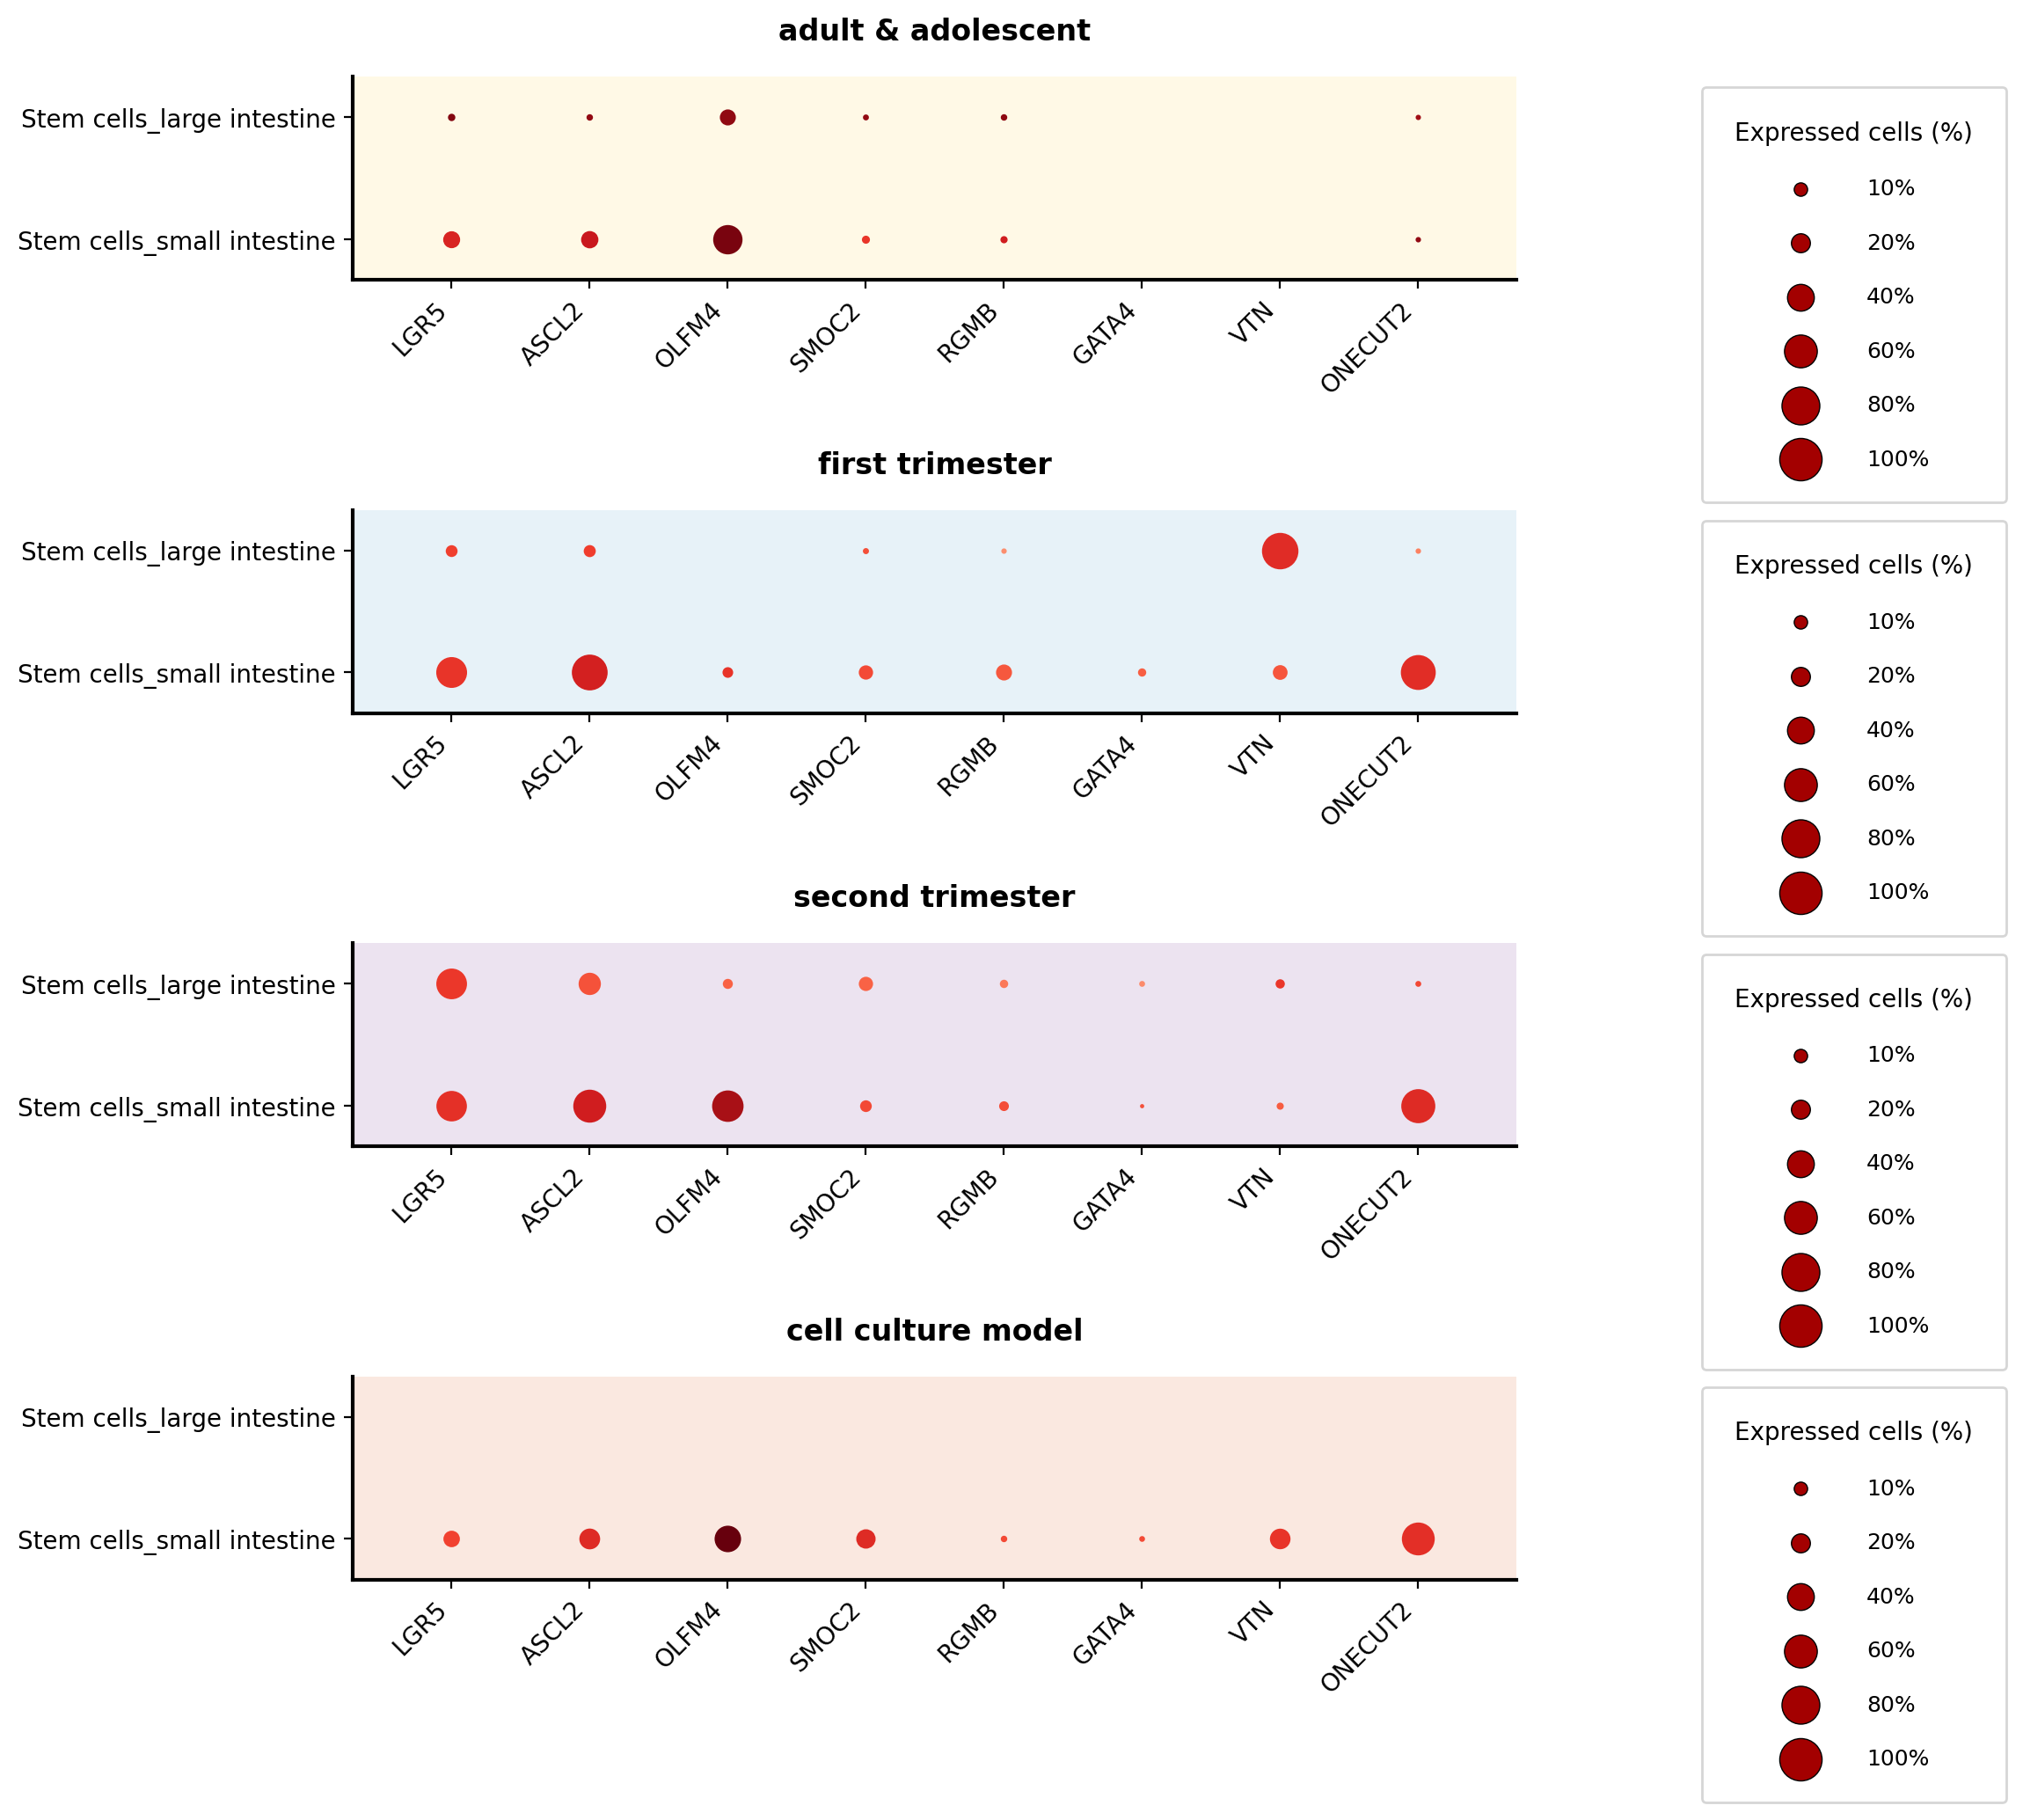

In [17]:
plt.style.use('default')
fig = plt.figure(figsize=(12, 10))  

# Define background colors for each plot
bg_colors = {
    'adult & adolescent': '#FFF9E6',
    'first trimester': '#e7f2f8',
    'second trimester': '#ece3f0',
    'cell culture model': '#fae8e0'
}

# Create subplot for each group
groups = ['adult & adolescent', 'first trimester', 'second trimester', 'cell culture model']
cell_types = ['Stem cells_small intestine', 'Stem cells_large intestine']

for idx, group in enumerate(groups, 1):
    ax = plt.subplot(4, 1, idx)
    
    # Set background color
    ax.set_facecolor(bg_colors[group])
    
    # Plot dots for this group
    for j, cell_type in enumerate(cell_types):
        for k, gene in enumerate(all_genes):
            data = stats_df[
                (stats_df['group'] == group) &
                (stats_df['cell_type'] == cell_type) &
                (stats_df['gene'] == gene)
            ]
            
            if not data.empty:
                size = data['pct_expressed'].iloc[0]
                color = data['mean_expression'].iloc[0]
                
                # Use compressed x-coordinates
                ax.scatter(
                    k * 0.7,  # Multiply by 0.7 to reduce horizontal spacing
                    j*0.3,
                    s=size*3,
                    c=[color],
                    cmap='Reds',
                    vmin=0,
                    vmax=stats_df['mean_expression'].max(),
                    edgecolor=None,
                    linewidth=1
                )
    
    # Adjust y-ticks to match new spacing
    ax.set_yticks(
        [i*0.3 for i in range(len(cell_types))],
        cell_types,
        fontsize=10
    )
    
    # Reduce top margin by adjusting y-axis limits
    ax.set_ylim(-0.1, 0.4)  # Adjusted from (-0.2, 0.7) to reduce top space
    
    # Adjust x-ticks to match compressed spacing
    ax.set_xticks(
        [k * 0.7 for k in range(len(all_genes))],  # Match the compressed x-coordinates
        all_genes,
        rotation=45,
        ha='right',
        fontsize=10
    )
    
    # Add spines styling
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Set x-axis limits to match compressed spacing
    ax.set_xlim(-0.5, (len(all_genes) - 1) * 0.7 + 0.5)
    
    # Add title with reduced padding
    ax.set_title(group, fontsize=12, fontweight='bold', pad=15)  # Reduced pad from 20 to 15

    # Modified legend for dot size with increased spacing
    sizes = [10, 20, 40, 60, 80, 100]
    legend_elements = []
    for s in sizes:
        scatter = plt.scatter([], [], 
                            s=s*3,
                            c='#A30000', 
                            label=f'{s}%', 
                            edgecolor='black', 
                            linewidth=0.5)
        legend_elements.append(scatter)

    # Create legend with increased spacing
    legend = ax.legend(handles=legend_elements, 
                    title='Expressed cells (%)', 
                    bbox_to_anchor=(1.15, 1), 
                    loc='upper left',
                    title_fontsize=10,
                    fontsize=9,
                    labelspacing=1.5,
                    handletextpad=2,
                    borderpad=1.5)

# Adjust layout
plt.tight_layout()

# Save the plots
plt.savefig('8_figures_for_paper_creation/figures/Figure1C_stem_cell_markers_expression_gene_expression_dotplot_subplots.png', dpi=300, bbox_inches='tight')
#plt.savefig('gene_expression_dotplots.svg', format='svg', bbox_inches='tight')

plt.show()

## Suplementary Table 1 - DEG for cell states

In [19]:
sc.tl.rank_genes_groups(adata_log, groupby='cell_states', method='wilcoxon', n_genes=100)

ranking genes


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:429: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:431: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.co

    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:28:54)


/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:455: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:429: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "na

In [20]:
df = sc.get.rank_genes_groups_df(adata_log, group=None)

In [ ]:
df.to_csv('8_figures_for_paper_creation/figures/cell_states_DEGs.csv')

## Suplementary figure - dot plot with markers for cell states

In [60]:
adata_log_epi = adata_log[adata_log.obs['celltype'].isin(['B cells', 'Plasma cells'])].copy()

In [67]:
adata_log_epi = adata_log[adata_log.obs['celltype'].isin(['Endothelial'])].copy()

In [68]:
cell_states = adata_log_epi.obs['cell_states'].unique().tolist()

+ Epithelial

In [135]:
markers_epi = {
    'Stem cells': ['LGR5', 'OLFM4', 'ASCL2', 'SMOC2', 'RGMB'],
    'TA': ['MKI67', 'TOP2A'],
    'EECs': ['CHGB','NEUROD1', 'TPH1'],
    'BEST4+ epithelial': ['BEST4', 'OTOP2'],
    'Enterocyte': ['FABP1', 'ALPI'],
    'Proximal progenitor': ['ONECUT2', 'GUCA2A'],
    'Goblet cell': ['MUC2', 'TFF3'],
    'CLDN10+ cells': ['CLDN10', 'SLC4A4'],
    'Colonocyte': ['CA2', 'AQP8'],
    'Distal progenitor': ['LEFTY1', 'DMBT1'],
    'Tuft': ['POU2F3', 'TRPM5'],
    'Paneth': ['DEFA5', 'LYZ'],
    'mature Goblet cell': ['CLCA1', 'ZG16'],
    'Microfold cells': ['GP2', 'SPIB'],
    'immature Goblet cell': ['KLF4', 'ATOH1'],
    'M/X cells (MLN/GHRL+)': ['GHRL', 'MLN'],
    'D cells (SST+)': ['SST'],
    'EC cells (TAC1+)': ['TAC1', 'TPH1'],
    'I cells (CCK+)': ['CCK'],
    'N cells (NTS+)': ['NTS'],
    'L cells (PYY+)': ['PYY', 'GCG'],
    'K cells (GIP+)': ['GIP']
}

In [ ]:
adata_subset = adata_log[adata_log.obs['celltype'].isin(['Epithelial'])].copy()

adata_subset.obs['cell_states'] = adata_subset.obs['cell_states'].astype(str)

adata_subset.obs.loc[
    adata_subset.obs['cell_states'] == 'Deep crypt secretory cells', 
    'cell_states'
] = adata_subset.obs['cellstates_scANVI'].astype(str)

with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(10, 10))
    sc.pl.dotplot(adata_subset, markers_epi, groupby='cell_states', dendrogram=True, show=False,swap_axes = False, cmap='plasma_r')
    plt.savefig(f"8_figures_for_paper_creation/figures/epi_cell_states_dotplot_markers_{timestamp}.png", bbox_inches="tight")
    plt.show()

+ Mesenchymal

In [144]:
markers_mes = {
    'Pericyte': ['NOTCH3', 'MCAM', 'RGS5', 'KCNJ8'],
    'Mesothelium': ['KRT19', 'LRRN4', 'UPK3B', 'PRG4', 'RGS5'],
    'Myofibroblast (RSPO2+)': ['RSPO2', 'ACTA2', 'DES'],
    'Cycling pericyte': ['RGS5', 'MKI67', 'TOP2A', 'PCLAF'],
    'Stromal 2 (NPY+)': ['NPY', 'PDGFRA','BMP4', 'F3', 'NPY', 'CH25H', 'MMP1', 'FRZB', 'BMP5'],
    'Mesoderm 1(HAND1+)': ['HAND1', 'HAND2', 'PITX2'],
    'Cycling stromal': ['MKI67', 'STMN1'],
    'Immature pericyte': ['PDGFRB', 'DES'],
    'Myofibroblast': ['ACTA2', 'TAGLN', 'DCN', 'RSPO2'],
    'Stromal 3 (KCNN3+)': ['KCNN3', 'LRRC3B', 'C7'],
    'Mesoderm 2(ZEB2+)': ['ZEB2'],
    'SMC (PLPP2+)': ['DES', 'CNN1', 'ACTA2', 'PLPP2'],
    'Stromal 1 (ADAMDEC1+)': ['ADAMDEC1', 'ADAM28','CCL11', 'FABP5', 'COL6A5'],
    'Stromal 2 (CH25H+)': ['CH25H', 'PDGFRA','BMP4', 'F3', 'NPY', 'CH25H', 'MMP1', 'FRZB', 'BMP5'],
    'SMC (PART1/CAPN3+)': ['DES', 'CNN1', 'ACTA2', 'PART1', 'CAPN3'],
    'Stromal 3 (C7+)': ['C7'],
    'ICC': ['KIT', 'ANO1', 'ETV1', 'SPON2'],
    'Angiogenic pericyte': ['NOTCH3', 'MCAM', 'RGS5', 'KCNJ8', 'PRRX1','PROCR', 'ENPEP', 'ABCC8', 'COL25A1', 'TEX41'],
    'Contractile pericyte': ['NOTCH3', 'MCAM', 'RGS5', 'KCNJ8', 'ACTA2', 'PLN', 'RERGL', 'KCNA5', 'KCNAB1', 'NRIP2'],
    'T reticular': ['CCL19', 'CCL21', 'LTBR'],
    'Transitional Stromal 3 (C3+)': ['C3', 'CXCL13', 'CCL21'],
    'Lymphoid_Stroma': ['CCL19', 'CCL21', 'LTBR', 'CXCL13', 'CR1', 'MADCAM1']
}

In [ ]:
adata_subset = adata_log[adata_log.obs['celltype'].isin(['Mesenchymal'])].copy()
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(10, 10))
    sc.pl.dotplot(adata_subset, markers_mes, groupby='cell_states', dendrogram=True, show=False, swap_axes = False, cmap='plasma_r')
    plt.savefig(f"8_figures_for_paper_creation/figures/mesenchymal_cell_states_dotplot_markers_{timestamp}.png", bbox_inches="tight")
    plt.show()

+ T cells

In [125]:
markers_t = {
    'CD8 Tmem': ['CD8A', "GZMB", "PRF1", "GNLY", "GZMH","CX3CR1", "KLRG1", "FGFBP2","TBX21", "EOMES", "ZEB2"],
    'NK cells': ['XCL2', 'NKG7',"NCAM1", "FCGR3A", "KLRF1", "EOMES", "GZMB", "PRF1", "GNLY"],
    'ILC3': ['IL4I1', 'RORC', 'KIT'],
    'CLP': ['IL7R', 'CD34'],
    'Cycling T': ["MKI67", "PCNA" ,"TOP2A", "UBE2C"],
    'Tfh': ["ICOS", "CXCR5","BCL6", "ASCL2"],
    'gamma delta T cells': ['TRDC', "TRDC", "TRGC1", "TRGC2", "CD3D", "IL7R"],
    'Activated T': ['CD69', "FOS", "JUN"],
    'Naive CD8 T cells': ["CD8A", "CCR7", "SELL"],
    'Activated CD8 T': ['CD8A', "CD69","FOS", "JUN"],
    'Activated CD4 T': ['CD4', "KLRB1", "AQP3", "CD69", "CD38", "IL2RA", 'FOS', 'JUN'],
    'Naive CD4 T cells': ['CD4', "CCR7", "SELL", "TCF7", "LEF1"],
    'NK T cell': ['NKG7', 'GNLY',"KLRB1", "ZBTB16","CD3D", "CD3E", "GATA3"],
    'TRM cytotoxic T': ['CD8A', "ITGA1", "ITGAE", "CXCR6", "CD69", "RUNX3", "ZNF683", "PRDM1"],
    'Treg': ["FOXP3", "IL2RA", "CTLA4", "TIGIT", "TNFRSF4", "TNFRSF18"],
    'MAIT cell': ['KLRB1', 'SLC4A10'],
    'ILC2': ['GATA3', 'KLRG1', 'HPGDS'],
    'Th17': [ "RORC", "STAT3"],
    'ILCP': ["ZBTB16","GATA3"]
}

In [ ]:
adata_subset = adata_log[adata_log.obs['celltype'].isin(['T cells'])].copy()
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(10, 10))
    sc.pl.dotplot(adata_subset, markers_t, groupby='cell_states', dendrogram=True, show=False, swap_axes = False, cmap='plasma_r')
    plt.savefig(f"8_figures_for_paper_creation/figures/t_cell_states_dotplot_markers_{timestamp}.png", bbox_inches="tight")
    plt.show()

+ B and Plasma

In [ ]:
markers_plasma_b = {
    'CLP': ['IL7R', 'CD27', 'SELL', 'ATXN1'],
    'ProB cells': ['MME', 'DNTT', 'IGLL1'],
    'PreB cells': ['MME', 'CD24','IGLL5'],
    'Cycling B cell': ['MKI67', 'TOP2A', 'CD19'],
    'PreproB cells': ['CD34', 'SPINK2', 'IL7R', 'ZCCHC7', 'RAG1'],
    'IgA plasma cell': ['IGHA1', 'IGHA2', 'CCR10'],
    'IgM plasma cell': ['IGHM', 'CXCR4'],
    'Naive B cells': ['SELL', 'IGHM', 'TCL1A'],
    'Plasma cells': ['XBP1', 'MZB1', 'JCHAIN', 'IGKC', 'IGLC2', 'IGLC3'],
    'Cycling plasma cell': ['SDC1', 'MKI67', 'PRDM1'],
    'Memory B cells': ['CR2', 'CD27', 'MS4A1', 'FCRL4'],
    'Germinal Center B cells': ['POU2AF1', 'CD40', 'SUGCT']
}

In [ ]:
adata_subset = adata_log[adata_log.obs['celltype'].isin(['B cells', 'Plasma cells'])].copy()
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(10, 10))
    sc.pl.dotplot(adata_subset, markers_plasma_b, groupby='cell_states', dendrogram=True, show=False, swap_axes = False, cmap='plasma_r')
    plt.savefig(f"8_figures_for_paper_creation/figures/B_plasma_cell_states_dotplot_markers_{timestamp}.png", bbox_inches="tight")
    plt.show()

* Myeloid

In [ ]:
markers_myeloid = {
    'cDC2': ['CD1C', 'CLEC10A'],
    'LYVE1+ macrophages': ['LYVE1', 'FOLR2', 'MARCO'],
    'CMP': ['KIT', 'CD34'],
    'Classical monocytes': ['CD14', 'LYZ', 'S100A8'],
    'Cycling monocytes': ['CD14', 'MKI67', 'TOP2A'],
    'Megakaryocyte': ['PPBP', 'PF4'],
    'Mast cells': ['TPSB2', 'TPSAB1', 'CPA3'],
    'Macrophages': ['CD68', 'MRC1'],
    'Cycling DC': ['MKI67'],
    'cDC1': ['CLEC9A', 'XCR1', 'BATF3'],
    'pDC': ['LILRA4', 'TCF4'],
    'Migratory DC': ['CCR7', 'LAMP3'],
    'MMP9+ inflammatory macrophages': ['MMP9', 'IL1B', 'CD14']
}

In [ ]:
adata_subset = adata_log[adata_log.obs['celltype'].isin(['Myeloid'])].copy()
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(10, 10))
    sc.pl.dotplot(adata_subset, markers_myeloid, groupby='cell_states', dendrogram=True, show=False, swap_axes = False, cmap='plasma_r')
    plt.savefig(f"8_figures_for_paper_creation/figures/myeloid_cell_states_dotplot_markers_{timestamp}.png", bbox_inches="tight")
    plt.show()

+ Neuronal

In [ ]:
markers_neuronal = {
    'Branch A': ['ETV1', 'GAL', 'NOS1', 'VIP', 'NTNG1', 'NXPH2'],
    'Progenitor': ['SOX10', 'PLP1', 'S100B'],
    'Branch B': ['BNC2', 'NXPH4', 'NDUFA4L2', 'PENK','DLX3', 'NTRK3','SST'],
    'Neuroblast': ['ASCL1', 'SOX11'],
    'Glia': [ 'S100B', 'CRYAB', 'MPZ']
}

In [ ]:
adata_subset = adata_log[adata_log.obs['celltype'].isin(['Neuronal'])].copy()
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(10, 10))
    sc.pl.dotplot(adata_subset, markers_neuronal, groupby='cell_states', dendrogram=True, show=False, swap_axes = False, cmap='plasma_r')
    plt.savefig(f"8_figures_for_paper_creation/figures/neuronal_cell_states_dotplot_markers_{timestamp}.png", bbox_inches="tight")
    plt.show()

* Endothelial

In [ ]:
markers_endothelial = {
    'LEC': ["PROX1", "PDPN", "LYVE1", "FLT4", "CCL21", "COLEC12", "TBX1", "FOXC2"],
    'Venous EC': ['ACKR1', 'VWF'],
    'venous capillary': ["RGCC", "VWA1"],
    'cycling EC': ["MKI67", "TOP2A", 'UBE2C'],
    'Arterial EC': ['GJA4', 'HEY1', 'HEY2', 'EFNB2'],
    'arterial capillary': ["CA4", "FCN3", "RGCC", "VWA1"]
}

In [ ]:
adata_subset = adata_log[adata_log.obs['celltype'].isin(['Endothelial'])].copy()
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(10, 10))
    sc.pl.dotplot(adata_subset, markers_endothelial, groupby='cell_states', dendrogram=True, show=False, swap_axes = False, cmap='plasma_r')
    plt.savefig(f"8_figures_for_paper_creation/figures/endothelial_cell_states_dotplot_markers_{timestamp}.png", bbox_inches="tight")
    plt.show()

### Unused Figure - appearance of cell states during the developmental process

In [83]:
def convert_timepoint_to_numeric(timepoint):
    """
    Converts timepoint strings (e.g., '14.4 week', '25 to 30 year') to numeric values
    for proper sorting of developmental timeline.
    """
    if "week" in timepoint:
        value = float(timepoint.split(" ")[0])
        return value / 52  # Convert weeks to years
    elif "year" in timepoint:
        # Handle ranges like "25 to 30 year"
        if "to" in timepoint:
            parts = timepoint.split(" ")
            avg = (float(parts[0]) + float(parts[2])) / 2
            return avg
        else:
            return float(timepoint.split(" ")[0])
    return 0

In [84]:
timepoints = list(adata.obs['full_age'].unique())
cell_states = list(adata.obs['cell_states'].unique())

In [85]:
sorted_timepoints = sorted(timepoints, key=convert_timepoint_to_numeric)

In [86]:
count_data = []
for state in cell_states:
    for tp in timepoints:
        mask = (adata.obs['cell_states'] == state) & (adata.obs['full_age'] == tp)
        count = np.sum(mask)
        count_data.append({
            'cell_state': state,
            'timepoint': tp,
            'count': count
        })

In [87]:
df = pd.DataFrame(count_data)
pivot_df = df.pivot(index='cell_state', columns='timepoint', values='count')
pivot_df = pivot_df[sorted_timepoints]

In [88]:
percent_df = pivot_df.copy()
for col in percent_df.columns:
    col_sum = pivot_df[col].sum()
    if col_sum > 0:
        percent_df[col] = (pivot_df[col] / col_sum) * 100

In [89]:
percent_df

timepoint,6.7 week,7.4 week,8.1 week,8.4 week,8.5 week,8.7 week,8.9 week,9.9 week,10.3 week,10.4 week,...,4 year,6 year,9 year,10 year,12 year,25 to 30 year,45 to 50 year,60 to 65 year,65 to 70 year,70 to 75 year
cell_state,,,,,,,,,,,,,,,,,,,,,
Activated CD4 T,0.000000,0.000000,0.000000,0.019330,0.000000,0.000000,0.000000,0.000000,0.059336,0.000000,...,2.304989,9.923213,4.539775,4.935330,8.142202,0.000000,1.657459,0.233781,0.000000,0.919540
Activated CD8 T,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.063045,0.000000,...,1.953619,7.383343,11.078717,5.377808,33.256881,0.059347,0.920810,0.467563,0.000000,0.996169
Activated T,0.017721,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.020743,0.007417,0.021352,...,0.773015,3.130538,2.290712,1.123213,5.619266,0.000000,4.972376,0.526008,0.000000,1.149425
Angiogenic pericyte,0.041349,0.000000,0.015574,0.000000,0.000000,0.014432,0.000000,0.020743,0.003709,0.042703,...,0.000000,0.000000,0.000000,0.000000,0.114679,0.019782,0.000000,0.175336,0.000000,0.000000
Arterial EC,0.318979,0.000000,0.576234,0.576024,0.000000,0.014432,0.000000,0.000000,1.357315,0.832711,...,0.112439,0.088600,0.166597,0.102110,0.114679,0.415430,0.000000,0.818235,3.291925,0.306513
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
gamma delta T cells,0.029535,0.000000,0.015574,0.170101,0.000000,0.000000,0.000000,0.041485,0.163174,0.053379,...,2.825018,5.729474,4.123282,7.317903,5.045872,0.138477,4.327808,2.571596,0.000000,7.432950
immature Goblet cell,0.059070,0.064725,0.000000,0.386593,0.000000,0.057728,0.038030,0.373367,1.913592,0.085406,...,0.744905,0.383934,0.458142,0.238257,0.114679,0.178042,0.092081,0.058445,0.000000,0.229885
mature Goblet cell,0.023628,0.258900,0.000000,0.309274,0.069614,0.000000,0.019015,0.082970,0.778787,0.074730,...,0.252987,0.472534,0.291545,0.442478,0.802752,0.158259,0.644567,0.350672,0.248447,5.057471


In [ ]:
cell_states_clean = [state for state in cell_states if state and not pd.isna(state)]
percent_df_clean = percent_df.loc[cell_states_clean]

In [91]:
# Create a map of cell states to cell types
cell_type_map = {}
for state in cell_states_clean:
    # Find all cells with this state
    cells_with_state = adata.obs[adata.obs['cell_states'] == state]
    if len(cells_with_state) > 0:
        # Get most common cell type for this state
        cell_type = cells_with_state['celltype'].value_counts().idxmax()
        if cell_type not in cell_type_map:
            cell_type_map[cell_type] = []
        cell_type_map[cell_type].append(state)

In [92]:
cell_type_map = {}
for state in cell_states_clean:
    # Find all cells with this state
    cells_with_state = adata.obs[adata.obs['cell_states'] == state]
    if len(cells_with_state) > 0:
        # Get most common cell type for this state
        cell_type = cells_with_state['celltype'].value_counts().idxmax()
        if cell_type not in cell_type_map:
            cell_type_map[cell_type] = []
        cell_type_map[cell_type].append(state)

In [95]:
# Loop through cell types and plot each one separately
for cell_type, states in cell_type_map.items():
    # Skip if no states for this cell type
    if not states:
        continue
    
    # Filter dataframe for this cell type
    subset_df = percent_df_clean.loc[states]
    
    # Adjust figure size based on number of states
    height = max(5, len(states) * 0.5)
    
    # Plot
    plt.figure(figsize=(20, height))
    ax = sns.heatmap(subset_df, 
                cmap="magma_r",
                linewidths=0,
                linecolor='none',
                cbar_kws={"label": "% of Cells", "shrink": 0.8})
    
    # Set y-tick positions
    ax.set_yticks(np.arange(len(states)) + 0.5)
    ax.set_yticklabels(states, rotation=0)
    
    # Set titles and labels
    plt.title(f"{cell_type} Cell State Distribution", fontsize=16)
    plt.ylabel("Cell State", fontsize=14)
    plt.xlabel("Developmental Timepoint", fontsize=14)
    plt.xticks(rotation=90, fontsize=12)
    plt.yticks(fontsize=12)
    
    # Remove grid lines and borders
    ax.grid(False)
    plt.tick_params(axis='both', which='both', length=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False) 
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    # Adjust colorbar
    cbar = plt.gcf().axes[-1]
    cbar.tick_params(labelsize=12)
    cbar.set_ylabel(cbar.get_ylabel(), fontsize=14)
    
    plt.tight_layout()
    
    # Clean filename
    clean_name = cell_type.replace(" ", "_").replace("/", "_").lower()
    plt.savefig(f'8_figures_for_paper_creation/figures/{clean_name}_appearance_during_development_{timestamp}.png', dpi=300, bbox_inches='tight')
    plt.close()